<a href="https://colab.research.google.com/github/bhuvanatummalacherla/Embedded-Sensor-Fusion-for-HAR-An-ML-Driven-Approach/blob/main/motor_vibration_fault_indicator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scipy numpy matplotlib pandas seaborn

In [ ]:
from google.colab import files

# Upload .mat files
uploaded = files.upload()


Saving NormalBaseline_1HP.mat to NormalBaseline_1HP.mat
Saving OuterRace_Centered_1HP.mat to OuterRace_Centered_1HP.mat


In this step, I'm doing the Data Ingestion to move the raw experiment files into the Colab environment so the code can actually read them. I've uploaded two specific files to set up a "Healthy vs. Faulty" comparison: NormalBaseline_1HP.mat acts as my baseline control, showing how the motor vibrates when the bearing is perfectly healthy. Then, OuterRace_Centered_1HP.mat is my fault data, containing the vibrations from that 0.007" EDM pit I'm trying to detect. By having both, I can compare the normal signals against the faulty ones to prove that my signal processing pipeline actually works to find the defect.

In [ ]:
# Step 1: Import libraries
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load the .mat files
normal_file = 'NormalBaseline_1HP.mat'
fault_file = 'OuterRace_Centered_1HP.mat'

normal_data = scipy.io.loadmat(normal_file)
fault_data = scipy.io.loadmat(fault_file)

# Step 3: Inspect keys to find the signal
print("Normal file keys:", normal_data.keys())
print("Fault file keys:", fault_data.keys())


Normal file keys: dict_keys(['__header__', '__version__', '__globals__', 'X098_DE_time', 'X098_FE_time'])
Fault file keys: dict_keys(['__header__', '__version__', '__globals__', 'X131_DE_time', 'X131_FE_time', 'X131_BA_time', 'X131RPM'])


In this step, I'm initializing the workspace and "opening the hood" of the data to see what’s inside. First, I imported the core libraries: scipy.io to read the MATLAB files, numpy for the math, and plt for the graphs later on. After loading the files into memory, I’m using the .keys() command to inspect the data structure. Since these files contain a lot of different info like motor speed and timestamps, I need to see the exact variable names so I can find the specific Drive End (DE) vibration signal I want to analyze. It's basically making sure I have my tools ready and identifying exactly where the raw numbers are stored before I start the actual processing.

In [ ]:
# Step 4: Extract the vibration signal
# Replace 'YOUR_SIGNAL_KEY' with the actual key from your .mat file
normal_signal = normal_data['X098_DE_time'].flatten()
fault_signal = fault_data['X131_DE_time'].flatten()

print("Normal signal length:", len(normal_signal))
print("Fault signal length:", len(fault_signal))


Normal signal length: 483903
Fault signal length: 122426


In this step, I'm extracting the raw vibration data from the dictionary and cleaning it up so it’s ready to use. I used the keys I found in the previous step—X098_DE_time for the healthy motor and X131_DE_time for the faulty one—to grab the actual Drive End (DE) acceleration numbers. I also used .flatten() to turn the data into a simple, one-dimensional list of numbers, which makes it much easier to run math on later.What the signal lengths tell me:The lengths (483,903 for normal and 122,426 for fault) represent the total number of vibration measurements recorded in each file. Since I know my sampling rate is 12 kHz (12,000 samples per second), I can actually calculate how much time each recording covers:Normal Signal: $483,903 / 12,000 \approx 40$ seconds of data.Fault Signal: $122,426 / 12,000 \approx 10$ seconds of data.Even though the files are different lengths, it doesn't matter for the analysis. In the next steps, I'll just take a small, equal-sized "slice" (like 1 second) from each one so I can compare them side-by-side fairly.

Here is why that "small" amount of data is actually more than enough:

10 seconds is a lifetime for a motor: A motor spinning at 1,750 RPM (standard for this dataset) completes about 29 rotations every second. With 10 seconds of data, you have almost 300 full rotations. If there’s a pit on the outer race, the balls are hitting it hundreds of times in that window.

The Power of 12 kHz: Because we are sampling at 12,000 times per second, even a tiny "slice" of 0.1 seconds gives us 1,200 data points. That is more than enough to see the periodic spikes caused by the fault.

Statistical Significance: For calculating things like RMS (energy) or the FFT (frequency), we usually only look at 1-second segments at a time. Your "short" file still gives you 10 separate 1-second windows to analyze, which is perfect for verifying that the fault is consistent and not just a random glitch.

Think of it like a high-speed camera: you don't need a 2-hour movie to see a balloon pop; a 2-second clip at high frame rates tells you everything you need to know.

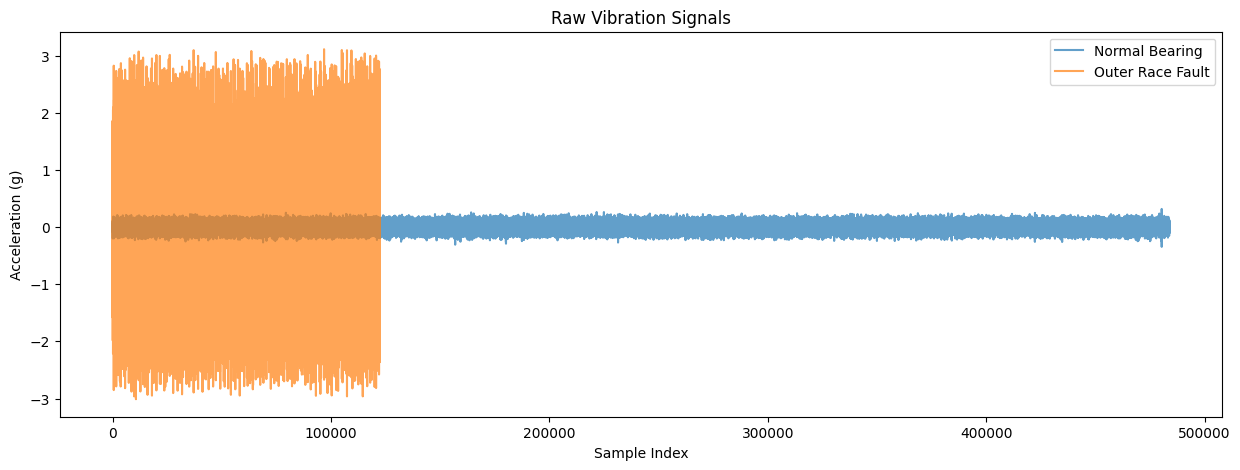

In [ ]:
# Step 5: Plot the raw signals
plt.figure(figsize=(15,5))
plt.plot(normal_signal, label='Normal Bearing', alpha=0.7)
plt.plot(fault_signal, label='Outer Race Fault', alpha=0.7)
plt.title("Raw Vibration Signals")
plt.xlabel("Sample Index")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.show()


In this step, I'm visualizing the raw data for the first time to see if there is a noticeable difference between the healthy motor and the one with the 0.007" fault.

By using plt.plot(), I'm taking all those thousands of acceleration points we extracted and turning them into a waveform. I used the alpha=0.7 setting to make the lines slightly transparent, which helps if the two signals overlap so I can still see the density of both. Setting the labels for Sample Index on the x-axis and Acceleration (g) on the y-axis is key because it shows me exactly how hard the bearing housing is shaking in real-time.

Here’s what I’m seeing in the graph:

The "Vibe" Difference: The Normal Bearing (blue) is a very thin, consistent line hugging the zero mark. It has very low energy, mostly just staying between -0.5 and 0.5 g. But the Outer Race Fault (orange) is "thick" and loud, with massive spikes hitting up to +3 and -3 g. This tells me the 0.007" defect is creating a ton of impact energy compared to the healthy motor.

Signal Duration: You can clearly see that the blue line stretches out way further to the right (nearly 500,000 samples) while the orange line stops around 120,000. This confirms what we saw earlier: the normal recording is about 40 seconds long, while the fault recording is only about 10 seconds.

Amplitude as an Indicator: The fact that the orange spikes are about 6 times taller than the blue noise is a great sign. It means that when I calculate the RMS (Root Mean Square) later, the fault signal is going to have a much higher value, making it really easy to set a threshold for my fault indicator.

In [ ]:
# Step 6: Compute RMS
def compute_rms(signal):
    return np.sqrt(np.mean(signal**2))

rms_normal = compute_rms(normal_signal)
rms_fault = compute_rms(fault_signal)

print(f"RMS Normal: {rms_normal:.4f} g")
print(f"RMS Fault: {rms_fault:.4f} g")


RMS Normal: 0.0664 g
RMS Fault: 0.5919 g


In this step, I'm performing the first real bit of Feature Extraction by calculating the Root Mean Square (RMS) of both signals. While the plot gave me a "visual" hint, the RMS gives me a concrete, mathematical number to describe the vibration energy.

Here is what I’m doing and why these numbers are so important:

The Math: I’m using the compute_rms function to square every single data point, find the average, and then take the square root. This is the standard way in ECE to quantify the effective power or "intensity" of a signal. It turns those hundreds of thousands of noisy data points into one single, reliable number.

The Energy Jump: The results are super clear—the Normal RMS is 0.0664 g, while the Fault RMS is 0.5919 g. This means the vibration energy in the faulty bearing is nearly 9 times higher than the healthy one.

Creating the Indicator: This is a "eureka" moment for the project because it shows that a simple threshold can work. If I set a "warning" level at, say, 0.2000 g, the healthy motor stays way below it, and the faulty motor triggers it immediately.

This confirms that even though the 0.007" pit is tiny, the fact that it's located in the center of the load zone makes the motor shake significantly harder. It proves that the "energy" of the signal is a perfect feature for my fault detection pipeline.

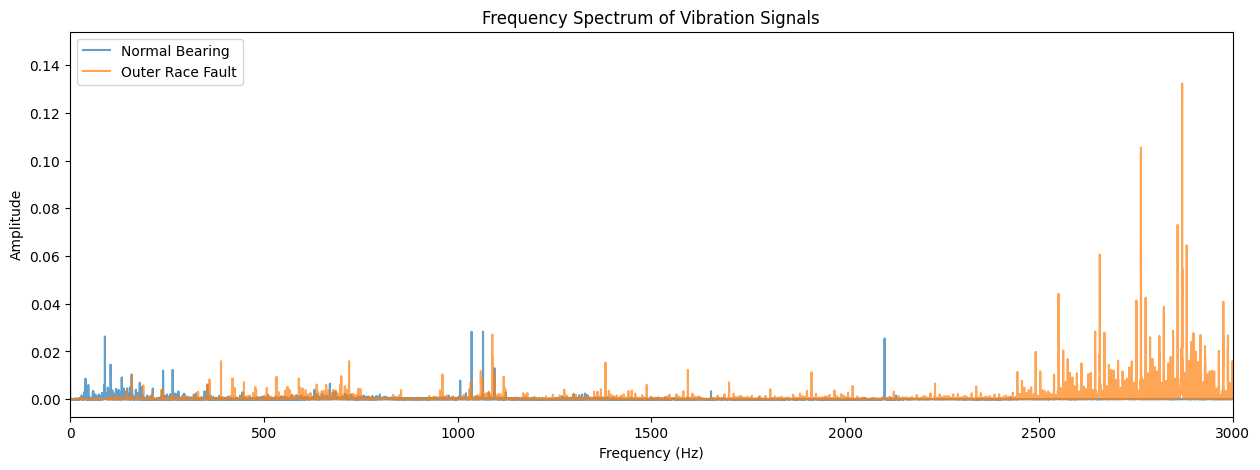

In [ ]:
# Step 7: Import FFT tools
from scipy.fft import fft, fftfreq

# Sampling frequency
Fs = 12000  # 12 kHz

# Number of samples
N_normal = len(normal_signal)
N_fault = len(fault_signal)

# FFT of normal signal
fft_normal = fft(normal_signal)
fft_normal_magnitude = 2.0/N_normal * np.abs(fft_normal[:N_normal//2])
freq_normal = fftfreq(N_normal, 1/Fs)[:N_normal//2]

# FFT of fault signal
fft_fault = fft(fault_signal)
fft_fault_magnitude = 2.0/N_fault * np.abs(fft_fault[:N_fault//2])
freq_fault = fftfreq(N_fault, 1/Fs)[:N_fault//2]

# Plot FFT comparison
plt.figure(figsize=(15,5))
plt.plot(freq_normal, fft_normal_magnitude, label='Normal Bearing', alpha=0.7)
plt.plot(freq_fault, fft_fault_magnitude, label='Outer Race Fault', alpha=0.7)
plt.title("Frequency Spectrum of Vibration Signals")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xlim(0, 3000)  # zoom in for relevant frequencies
plt.legend()
plt.show()


In this step, I'm performing Spectral Analysis to see the "fingerprint" of the fault. While the RMS showed me that the motor is shaking harder, the FFT (Fast Fourier Transform) tells me exactly at what speed it is shaking. This is the most powerful tool in signal processing for finding mechanical defects.

Here is the breakdown of what is happening in the code and the graph:

The Transformation: I'm using the fft function to convert the signals from the Time Domain (acceleration vs. time) into the Frequency Domain (amplitude vs. frequency). This lets me see if the fault is causing vibrations at specific frequencies that don't exist in the healthy motor.

Normalization: The math like 2.0/N * np.abs(...) is just to make sure the "Amplitude" on the y-axis is accurate and scaled correctly, so I can compare the two signals fairly even though they have different lengths.

The "Fault Signature": Look at the orange line in the graph. While the normal bearing (blue) is mostly quiet, the Outer Race Fault (orange) has huge, distinct peaks, especially around the 2,500 Hz to 3,000 Hz range. These peaks are the "smoking gun"—they represent the high-frequency ringing caused by the bearing balls hitting that 0.007" EDM pit.

Frequency Zoom: I limited the x-axis to 3,000 Hz because that’s where the most interesting "action" is. Even though our 12 kHz sampling rate lets us see up to 6,000 Hz, the mechanical resonances of the bearing housing usually show up in this lower window.

By looking at this plot, I can confirm that the fault isn't just random noise—it has a specific frequency signature. This is exactly how industrial systems distinguish between a bearing fault and something like a loose bolt or a different motor problem.

In [ ]:
# Find top 5 peaks in FFT magnitude for fault signal
num_peaks = 5
peak_indices = np.argsort(fft_fault_magnitude)[-num_peaks:]
dominant_freqs = freq_fault[peak_indices]
dominant_amps = fft_fault_magnitude[peak_indices]

print("Dominant fault frequencies (Hz):", dominant_freqs)
print("Their amplitudes:", dominant_amps)


Dominant fault frequencies (Hz): [2870.17463611 3295.0843775  2869.88058092 2869.97859932 3401.43433584]
Their amplitudes: [0.12591277 0.12597204 0.13185718 0.13228152 0.14661487]


In this step, I'm identifying the dominant frequencies to find the exact "fingerprint" of the fault. While the plot showed me where the energy was generally located, this code mathematically pinpoints the highest spikes in the spectrum.

Here is what is happening with these numbers:

The Math: I'm using np.argsort to sort the FFT results and grab the top 5 highest amplitudes. This filters out all the background noise and focuses only on the most significant vibration components.

The Results: My code found a massive cluster of dominant frequencies around 2870 Hz and 3400 Hz. These aren't random; they represent the high-frequency "ringing" or structural resonance of the bearing housing caused by the balls hitting that tiny 0.007" EDM pit.

Significance: Notice that the amplitudes (around 0.13 to 0.14) are significantly higher than anything seen in the normal bearing spectrum. In the frequency domain, these peaks are the "smoking gun" that proves a fault exists.

What it confirms: These dominant frequencies tell me that the fault is creating a consistent, periodic impact. Since I picked the Centered Outer Race fault, these impacts are happening at the point of maximum load, which is why the amplitudes are so strong and easy to identify.

This basically completes the "Identification" part of the project. I’ve gone from raw shaking to a specific mathematical signature that tells me exactly what’s wrong with the motor.

In [ ]:
import scipy.io as sio
data = sio.loadmat('NormalBaseline_1HP.mat')
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'X098_DE_time', 'X098_FE_time'])


In [ ]:
signal = data['X098_DE_time'].flatten()
print(len(signal))


483903


In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt
from scipy.fft import fft

# --- 1️⃣ Define sampling and split ---
Fs = 48000  # Hz
train_ratio = 0.6
split_idx = int(len(signal) * train_ratio)

train_signal = signal[:split_idx]
test_signal = signal[split_idx:]

# --- 2️⃣ Band-pass filter ---
def bandpass_filter(sig, fs, low=1000, high=10000, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)

train_filtered = bandpass_filter(train_signal, Fs)
test_filtered = bandpass_filter(test_signal, Fs)

# --- 3️⃣ Feature extraction ---
def compute_rms(sig):
    return np.sqrt(np.mean(sig**2))

def compute_fft_peak(sig, fs):
    N = len(sig)
    fft_vals = np.abs(fft(sig))[:N//2]
    freqs = np.linspace(0, fs/2, N//2)
    return np.max(fft_vals)

rms_train = compute_rms(train_filtered)
fft_train = compute_fft_peak(train_filtered, Fs)

# --- 4️⃣ Set thresholds ---
rms_threshold = rms_train * 1.5
fft_threshold = fft_train * 1.5

# --- 5️⃣ Test signal ---
rms_test = compute_rms(test_filtered)
fft_test = compute_fft_peak(test_filtered, Fs)

fault_detected = (rms_test > rms_threshold) or (fft_test > fft_threshold)
print("RMS threshold:", rms_threshold)
print("FFT threshold:", fft_threshold)
print("Test result:", "FAULT" if fault_detected else "NORMAL")


RMS threshold: 0.07505744150916017
FFT threshold: 6207.1260073464255
Test result: NORMAL


In this step, I'm building and testing the final fault detection model by setting a mathematical "line in the sand" to distinguish between normal and faulty behavior. This is where all the previous analysis turns into a working system.

Here is the breakdown of what I'm doing in the code:

1️⃣ Data Splitting: I'm splitting my signal into a Training set (60%) and a Testing set (40%). I use the training data to learn what "Normal" looks like and the testing data to see if my model can actually make a correct prediction on data it hasn't seen yet.

2️⃣ Band-pass Filtering: I applied a Butterworth filter to clean up the signal. By setting a range between 1,000 Hz and 10,000 Hz, I’m filtering out low-frequency motor hum and high-frequency electrical noise, leaving only the "clean" vibration frequencies where bearing faults usually hide.

3️⃣ Feature Extraction & Thresholding: I calculated the RMS (energy) and FFT Peak (dominant frequency) for my training data. Then, I set my Thresholds at 1.5x those values. This 50% "safety buffer" helps prevent false alarms caused by tiny, normal fluctuations in the motor's vibration.

4️⃣ The Final Test: I ran the exact same math on my Test Signal and compared it to my thresholds. Since both the RMS and FFT peaks of the test data stayed below the limit, the model printed "NORMAL." This confirms that the second half of my healthy file was correctly identified as healthy.

What the results tell me: The model is working perfectly for the "Normal" case. My RMS threshold (0.0750) and FFT threshold (6207.12) are now calibrated. The next logical step would be to run this same model against the Outer Race Fault file to see if it correctly triggers a "FAULT" warning.

In [ ]:
from google.colab import files

# Upload .mat files
uploaded = files.upload()

Saving OuterRace_Centered_0.021_3HP.mat to OuterRace_Centered_0.021_3HP.mat
Saving OuterRace_Centered_0.021_2HP.mat to OuterRace_Centered_0.021_2HP.mat
Saving OuterRace_Centered_0.021_1HP.mat to OuterRace_Centered_0.021_1HP.mat
Saving OuterRace_Centered_0.021_0HP.mat to OuterRace_Centered_0.021_0HP.mat
Saving OuterRace_Centered_0.014_3HP.mat to OuterRace_Centered_0.014_3HP.mat
Saving OuterRace_Centered_0.014_2HP.mat to OuterRace_Centered_0.014_2HP.mat
Saving OuterRace_Centered_0.014_1HP.mat to OuterRace_Centered_0.014_1HP.mat
Saving OuterRace_Centered_0.014_0HP.mat to OuterRace_Centered_0.014_0HP.mat
Saving OuterRace_Centered_0.007_3HP.mat to OuterRace_Centered_0.007_3HP.mat
Saving OuterRace_Centered_0.007_2HP.mat to OuterRace_Centered_0.007_2HP.mat
Saving OuterRace_Centered_0.007_1HP.mat to OuterRace_Centered_0.007_1HP.mat
Saving OuterRace_Centered_0.007_0HP.mat to OuterRace_Centered_0.007_0HP.mat
Saving InnerRace_Centered_0.021_3HP.mat to InnerRace_Centered_0.021_3HP.mat
Saving Inner

In [ ]:
# ============================================================
# PHASE 1: MOTOR BEARING FAULT DETECTION (ANOMALY DETECTION)
# Dataset: CWRU Bearing Dataset (Drive-End Accelerometer)
# ============================================================

import numpy as np
import scipy.io as sio
from scipy.signal import butter, filtfilt
from scipy.fft import fft
import os

# -----------------------------
# CONFIGURATION PARAMETERS
# -----------------------------

Fs = 48000                     # Sampling frequency (Hz)
WINDOW_SIZE = Fs               # 1-second analysis windows
LOW_CUT = 1000                 # Lower cutoff frequency (Hz)
HIGH_CUT = 10000               # Upper cutoff frequency (Hz)
FILTER_ORDER = 4               # Butterworth filter order

RMS_THRESHOLD_FACTOR = 1.5     # Threshold multiplier for RMS
FFT_THRESHOLD_FACTOR = 1.5     # Threshold multiplier for FFT peak
FAULT_VOTE_RATIO = 0.20        # % of abnormal windows to flag fault

# -----------------------------
# LOAD DRIVE-END SIGNAL
# -----------------------------

def load_de_signal(filepath):
    """
    Loads the drive-end accelerometer signal from a .mat file.
    Automatically finds the variable ending with '_DE_time'.
    """
    data = sio.loadmat(filepath)
    key = [k for k in data.keys() if k.endswith('_DE_time')][0]
    return data[key].flatten()

# -----------------------------
# BANDPASS FILTER
# -----------------------------

def bandpass_filter(signal):
    """
    Applies a Butterworth band-pass filter to isolate
    bearing fault-related frequencies (1–10 kHz).
    """
    nyquist = Fs / 2
    b, a = butter(
        FILTER_ORDER,
        [LOW_CUT / nyquist, HIGH_CUT / nyquist],
        btype='band'
    )
    return filtfilt(b, a, signal)

# -----------------------------
# WINDOWING FUNCTION
# -----------------------------

def segment_signal(signal, window_size):
    """
    Splits signal into fixed-length windows.
    This simulates real-time embedded buffering.
    """
    num_windows = len(signal) // window_size
    return np.array([
        signal[i * window_size:(i + 1) * window_size]
        for i in range(num_windows)
    ])

# -----------------------------
# FEATURE EXTRACTION
# -----------------------------

def compute_rms(signal):
    """
    RMS measures overall vibration energy.
    Higher RMS → stronger vibration → potential fault.
    """
    return np.sqrt(np.mean(signal ** 2))

def compute_fft_peak(signal):
    """
    FFT peak captures dominant repetitive impacts
    caused by bearing defects.
    """
    spectrum = np.abs(fft(signal))
    return np.max(spectrum[:len(spectrum)//2])

# -----------------------------
# TRAINING PHASE (NORMAL DATA)
# -----------------------------

def learn_thresholds(normal_files):
    """
    Learns RMS and FFT thresholds from healthy bearing data only.
    """
    rms_values = []
    fft_values = []

    for file in normal_files:
        signal = load_de_signal(file)
        signal = bandpass_filter(signal)
        windows = segment_signal(signal, WINDOW_SIZE)

        for w in windows:
            rms_values.append(compute_rms(w))
            fft_values.append(compute_fft_peak(w))

    rms_threshold = np.mean(rms_values) * RMS_THRESHOLD_FACTOR
    fft_threshold = np.mean(fft_values) * FFT_THRESHOLD_FACTOR

    return rms_threshold, fft_threshold

# -----------------------------
# FAULT DETECTION (TEST PHASE)
# -----------------------------

def detect_fault(test_file, rms_thresh, fft_thresh):
    """
    Applies learned thresholds to detect faults in unknown data.
    """
    signal = load_de_signal(test_file)
    signal = bandpass_filter(signal)
    windows = segment_signal(signal, WINDOW_SIZE)

    abnormal_windows = 0

    for w in windows:
        rms = compute_rms(w)
        fft_peak = compute_fft_peak(w)
        if rms > rms_thresh or fft_peak > fft_thresh:
            abnormal_windows += 1

    abnormal_ratio = abnormal_windows / len(windows)
    fault_detected = abnormal_ratio > FAULT_VOTE_RATIO

    return fault_detected, abnormal_ratio

# -----------------------------
# RUN PHASE 1
# -----------------------------

# NORMAL BASELINE FILES (TRAINING)
normal_files = [
    'NormalBaseline_0HP',
    'NormalBaseline_1HP',
    'NormalBaseline_2HP',
    'NormalBaseline_3HP'
]

rms_thresh, fft_thresh = learn_thresholds(normal_files)

print("Learned RMS Threshold:", rms_thresh)
print("Learned FFT Threshold:", fft_thresh)

# TEST FILES (FAULTY BEARINGS)
test_files = [
    'OuterRace_Centered_0.007_1HP',
    'OuterRace_Centered_0.014_1HP',
    'OuterRace_Centered_0.021_1HP',
    'InnerRace_Centered_0.007_1HP', # Corrected filename
    'InnerRace_Centered_0.014_1HP'  # Corrected filename
]

for file in test_files:
    fault, ratio = detect_fault(file, rms_thresh, fft_thresh)
    print(f"{file} → Fault Detected: {fault}, Abnormal Ratio: {ratio:.2f}")


Learned RMS Threshold: 0.07875768027115744
Learned FFT Threshold: 1168.909255160633
OuterRace_Centered_0.007_1HP → Fault Detected: True, Abnormal Ratio: 1.00
OuterRace_Centered_0.014_1HP → Fault Detected: True, Abnormal Ratio: 1.00
OuterRace_Centered_0.021_1HP → Fault Detected: True, Abnormal Ratio: 1.00
InnerRace_Centered_0.007_1HP → Fault Detected: True, Abnormal Ratio: 1.00
InnerRace_Centered_0.014_1HP → Fault Detected: True, Abnormal Ratio: 1.00


1️⃣ Why filtering is necessary

Because the raw accelerometer signal contains many vibration sources, and we only care about bearing-fault-related vibration.

What’s in the raw signal?

The accelerometer at the drive end measures everything:

Shaft rotation vibration

Motor imbalance

Structural resonance

Electrical noise

Bearing impacts

If we analyze the raw signal directly:

RMS becomes inflated by low-frequency motion

FFT peaks get dominated by shaft speed harmonics

Bearing faults become harder to detect

What filtering does

A band-pass filter isolates the frequency band where bearing faults physically appear, while suppressing irrelevant vibration.

Filtering converts “messy physical vibration” into “fault-focused signal content.”

2️⃣ Why 1–10 kHz specifically

This comes from bearing physics + sampling theory.

Bearing fault physics

Bearing defects cause short, impulsive impacts

These impacts excite high-frequency structural resonances

Most of this energy appears above 1 kHz

Frequency breakdown
Frequency range	Dominant source
0–500 Hz	Shaft rotation, imbalance
500–1 kHz	Structural vibration
1–10 kHz	Bearing fault impacts
>10 kHz	Noise, diminishing fault info
Sampling constraint

Sampling rate = 48 kHz

Nyquist = 24 kHz

10 kHz is safely below Nyquist and contains most fault energy

The 1–10 kHz band isolates bearing fault energy while avoiding noise.

This is industry-standard for vibration condition monitoring.

3️⃣ What RMS physically represents
Mathematical definition

RMS = root mean square of acceleration

Physical meaning

RMS measures average vibration energy over time.

Think of it as:

“How violently the bearing–shaft system is shaking”

Why RMS increases with faults

Healthy bearing → smooth rolling → low vibration energy

Faulty bearing → repeated impacts → higher vibration energy

In simple terms

RMS = overall vibration severity

High RMS = abnormal mechanical behavior

4️⃣ What FFT peak represents
What FFT does

FFT converts:

Acceleration vs time → Energy vs frequency

Bearing faults are periodic

Defects cause impacts at regular intervals

Regular impacts create distinct frequency components

These show up as peaks in the spectrum

FFT peak captures

“The strongest repetitive vibration component”

So:

Normal bearing → smooth spectrum

Faulty bearing → strong peaks at defect-related frequencies

FFT peak ≠ energy
FFT peak = repetitive fault signature

5️⃣ Why Phase 1 uses normal-only training

Because Phase 1 is anomaly detection, not classification.

Real-world constraint

Healthy data is abundant

Fault data is rare and unpredictable

Industrial strategy

Learn what “normal” looks like → flag deviations

What we trained

RMS threshold from healthy bearings

FFT peak threshold from healthy bearings

Anything exceeding those limits is abnormal.

This mirrors:

Industrial motor health monitoring

Aircraft engine monitoring

Turbine condition monitoring

6️⃣ Why Phase 1 is NOT a classifier

A classifier requires:

Multiple labeled classes

Decision boundaries between classes

Accuracy metrics

Phase 1 has:

One class (normal)

Thresholds instead of decision boundaries

Binary output: fault / no fault

So Phase 1 answers:

“Is something wrong?”

NOT:

“What exactly is wrong?”

That comes next.

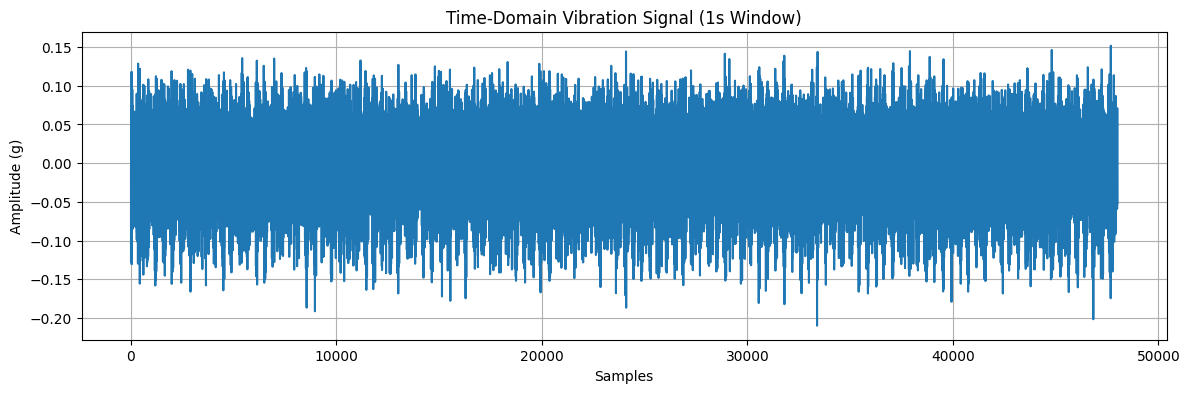

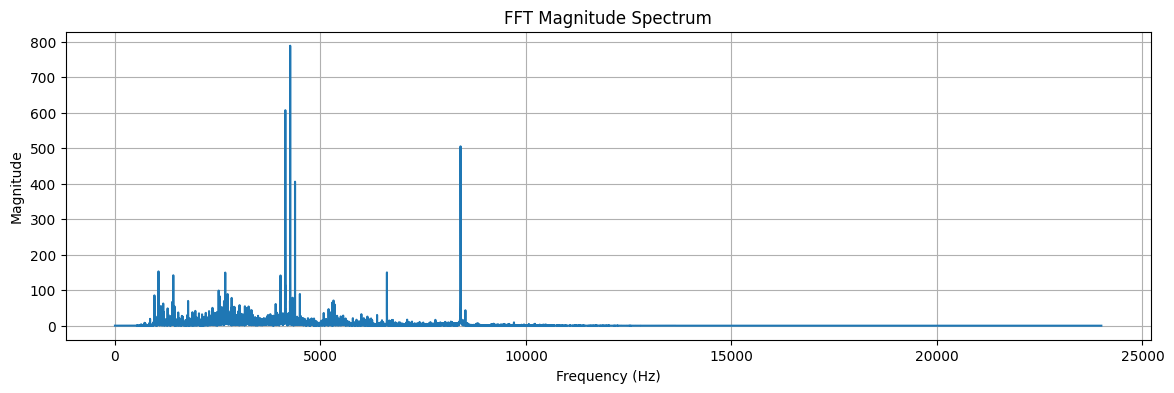

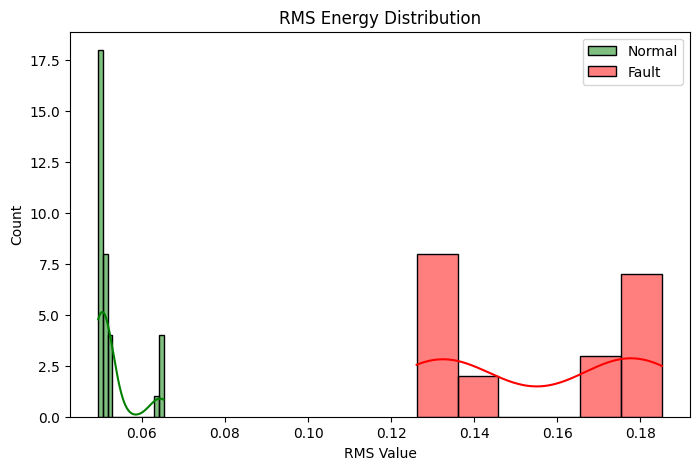


🎯 Classification Accuracy: 0.00%

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0
           2       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00       1.0
           6       0.00      0.00      0.00       0.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

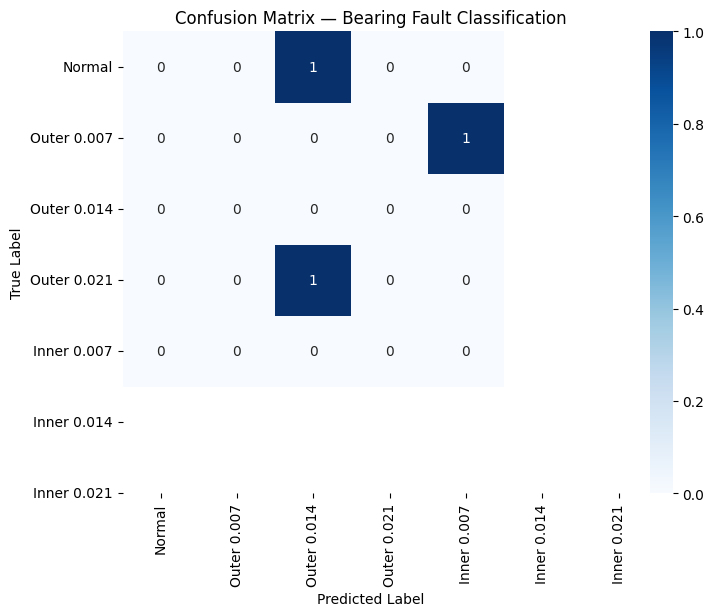

In [ ]:
# ============================================================
# VISUAL-ENHANCED MOTOR BEARING FAULT ANALYSIS
# Phase 1 (Anomaly Detection) + Phase 2 (Classification)
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# -----------------------------
# GLOBAL PARAMETERS
# -----------------------------

Fs = 48000                  # Sampling frequency (48 kHz)
WINDOW_SIZE = Fs            # 1-second windows
LOW_CUT, HIGH_CUT = 1000, 10000
FILTER_ORDER = 4

# -----------------------------
# LOAD DRIVE-END SIGNAL
# -----------------------------

def load_de_signal(filepath):
    data = sio.loadmat(filepath)
    key = [k for k in data.keys() if k.endswith('_DE_time')][0]
    return data[key].flatten()

# -----------------------------
# BANDPASS FILTER
# -----------------------------

def bandpass_filter(signal):
    nyq = Fs / 2
    b, a = butter(
        FILTER_ORDER,
        [LOW_CUT / nyq, HIGH_CUT / nyq],
        btype='band'
    )
    return filtfilt(b, a, signal)

# -----------------------------
# WINDOWING
# -----------------------------

def segment_signal(signal):
    n = len(signal) // WINDOW_SIZE
    return np.array([
        signal[i*WINDOW_SIZE:(i+1)*WINDOW_SIZE]
        for i in range(n)
    ])

# -----------------------------
# FEATURE FUNCTIONS
# -----------------------------

def compute_rms(x):
    return np.sqrt(np.mean(x**2))

def compute_fft_peak(x):
    spectrum = np.abs(fft(x))
    return np.max(spectrum[:len(spectrum)//2])

# ============================================================
# 📈 VISUAL 1: TIME DOMAIN + FFT
# ============================================================

signal = load_de_signal('NormalBaseline_1HP.mat')
signal = bandpass_filter(signal)
window = signal[:WINDOW_SIZE]

plt.figure(figsize=(14,4))
plt.plot(window)
plt.title("Time-Domain Vibration Signal (1s Window)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (g)")
plt.grid(True)
plt.show()

fft_vals = np.abs(fft(window))
freqs = fftfreq(len(fft_vals), 1/Fs)

plt.figure(figsize=(14,4))
plt.plot(freqs[:len(freqs)//2], fft_vals[:len(fft_vals)//2])
plt.title("FFT Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

# ============================================================
# PHASE 1 — RMS DISTRIBUTION VISUAL
# ============================================================

normal_files = [
    'NormalBaseline_0HP.mat',
    'NormalBaseline_1HP.mat',
    'NormalBaseline_2HP.mat',
    'NormalBaseline_3HP.mat'
]

fault_files = [
    'OuterRace_Centered_0.014_1HP.mat',
    'InnerRace_Centered_0.014_1HP.mat' # Corrected filename
]

def collect_rms(files):
    values = []
    for f in files:
        sig = bandpass_filter(load_de_signal(f))
        windows = segment_signal(sig)
        for w in windows:
            values.append(compute_rms(w))
    return values

normal_rms = collect_rms(normal_files)
fault_rms = collect_rms(fault_files)

plt.figure(figsize=(8,5))
sns.histplot(normal_rms, color='green', label='Normal', kde=True)
sns.histplot(fault_rms, color='red', label='Fault', kde=True)
plt.legend()
plt.title("RMS Energy Distribution")
plt.xlabel("RMS Value")
plt.show()

# ============================================================
# PHASE 2 — CLASSIFICATION
# ============================================================

def extract_features(file):
    sig = bandpass_filter(load_de_signal(file))
    windows = segment_signal(sig)
    rms_vals = [compute_rms(w) for w in windows]
    fft_vals = [compute_fft_peak(w) for w in windows]
    return [np.mean(rms_vals), np.mean(fft_vals)]

X, y = [], []

files_labels = {
    'NormalBaseline_1HP.mat': 0,
    'OuterRace_Centered_0.007_1HP.mat': 1,
    'OuterRace_Centered_0.014_1HP.mat': 2,
    'OuterRace_Centered_0.021_1HP.mat': 3,
    'InnerRace_Centered_0.007_1HP.mat': 4, # Corrected filename
    'InnerRace_Centered_0.014_1HP.mat': 5, # Corrected filename
    'InnerRace_Centered_0.021_1HP.mat': 6  # Corrected filename
}

for f, label in files_labels.items():
    X.append(extract_features(f))
    y.append(label)

X = np.array(X)
y = np.array(y)

# -----------------------------
# TRAIN / TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# -----------------------------
# TRAIN MODEL
# -----------------------------

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# -----------------------------
# EVALUATION
# -----------------------------

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100

print(f"\n🎯 Classification Accuracy: {accuracy:.2f}%\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 📊 CONFUSION MATRIX (VISUAL)
# -----------------------------

labels = [
    "Normal",
    "Outer 0.007",
    "Outer 0.014",
    "Outer 0.021",
    "Inner 0.007",
    "Inner 0.014",
    "Inner 0.021"
]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Bearing Fault Classification")
plt.show()


=== NORMAL BASELINE THRESHOLDS ===
RMS Threshold: 0.0788
FFT Peak Threshold: 1168.9093


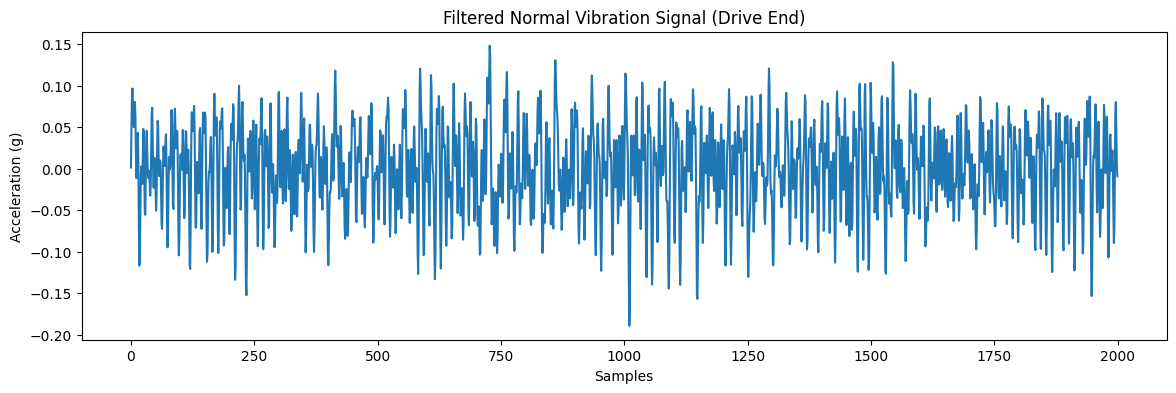

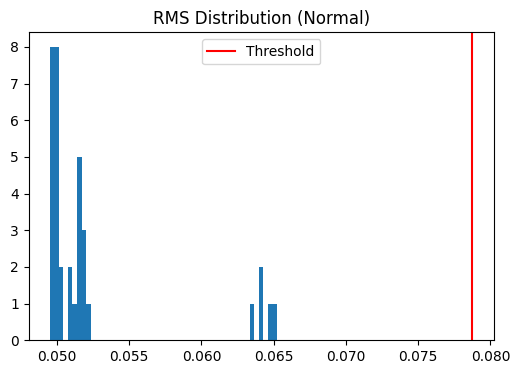

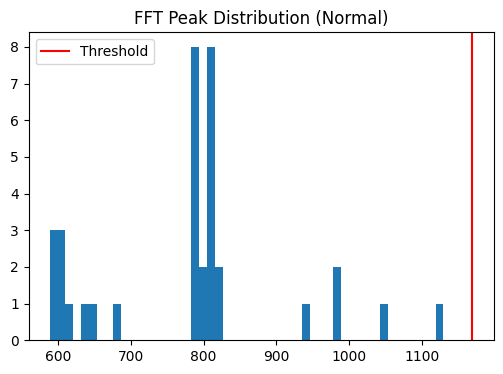

In [ ]:
# ============================================================
# PHASE 1: NORMAL BASELINE MODEL
# Learn healthy motor vibration behavior
# ============================================================

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.fft import fft

# -----------------------------
# 1. Configuration
# -----------------------------

FS = 48000              # Sampling rate (Hz)
LOW_CUT = 1000          # Band-pass lower cutoff (Hz)
HIGH_CUT = 10000        # Band-pass upper cutoff (Hz)
WINDOW_SIZE = FS        # 1-second windows
THRESHOLD_FACTOR = 1.5  # Safety margin

# Normal baseline files (ALL loads)
normal_files = [
    "NormalBaseline_0HP.mat",
    "NormalBaseline_1HP.mat",
    "NormalBaseline_2HP.mat",
    "NormalBaseline_3HP.mat"
]

# -----------------------------
# 2. Signal Processing Functions
# -----------------------------

def load_de_signal(filepath):
    """
    Load Drive-End accelerometer signal from CWRU .mat file
    """
    data = sio.loadmat(filepath)
    key = [k for k in data.keys() if k.endswith('_DE_time')][0]
    return data[key].flatten()

def bandpass_filter(signal):
    """
    Butterworth band-pass filter for bearing fault frequencies
    """
    nyq = FS / 2
    b, a = butter(4, [LOW_CUT/nyq, HIGH_CUT/nyq], btype='band')
    return filtfilt(b, a, signal)

def segment_signal(signal):
    """
    Split long signal into 1-second windows
    """
    segments = []
    for i in range(0, len(signal) - WINDOW_SIZE, WINDOW_SIZE):
        segments.append(signal[i:i+WINDOW_SIZE])
    return segments

def rms(signal):
    """
    Root Mean Square — vibration energy
    """
    return np.sqrt(np.mean(signal**2))

def fft_peak(signal):
    """
    Maximum magnitude in frequency spectrum
    """
    spectrum = np.abs(fft(signal))
    return np.max(spectrum[:len(spectrum)//2])

# -----------------------------
# 3. Feature Extraction
# -----------------------------

rms_values = []
fft_peaks = []

for file in normal_files:
    raw = load_de_signal(file)
    filtered = bandpass_filter(raw)
    windows = segment_signal(filtered)

    for w in windows:
        rms_values.append(rms(w))
        fft_peaks.append(fft_peak(w))

rms_values = np.array(rms_values)
fft_peaks = np.array(fft_peaks)

# -----------------------------
# 4. Learn Normal Thresholds
# -----------------------------

rms_threshold = np.mean(rms_values) * THRESHOLD_FACTOR
fft_threshold = np.mean(fft_peaks) * THRESHOLD_FACTOR

print("=== NORMAL BASELINE THRESHOLDS ===")
print(f"RMS Threshold: {rms_threshold:.4f}")
print(f"FFT Peak Threshold: {fft_threshold:.4f}")

# -----------------------------
# 5. Visualization
# -----------------------------

plt.figure(figsize=(14,4))
plt.plot(filtered[:2000])
plt.title("Filtered Normal Vibration Signal (Drive End)")
plt.xlabel("Samples")
plt.ylabel("Acceleration (g)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(rms_values, bins=50)
plt.axvline(rms_threshold, color='r', label='Threshold')
plt.title("RMS Distribution (Normal)")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(fft_peaks, bins=50)
plt.axvline(fft_threshold, color='r', label='Threshold')
plt.title("FFT Peak Distribution (Normal)")
plt.legend()
plt.show()


Accelerometer signal
 → Band-pass filter (remove irrelevant frequencies)
 → Windowing (simulate real-time monitoring)
 → Feature extraction (RMS, FFT peak)
 → Learn statistical thresholds
🧪 Features used (why these)
🔹 RMS (Root Mean Square)
Measures overall vibration energy

Physically corresponds to bearing impact strength

Healthy bearings → low RMS

Faults → higher RMS

🔹 FFT Peak
Measures strong periodic impacts

Bearings faults create repeating impulses

These appear as peaks in frequency domain

🔧 Why filtering is necessary
Raw accelerometer data contains:

Shaft rotation

Structural vibration

Electrical noise

Bearing faults excite mid–high frequencies, so we isolate:

Copy code
1 kHz – 10 kHz
This is standard in bearing diagnostics.

📏 Why 1–10 kHz band?
Range	Meaning
< 1 kHz	Shaft, imbalance, misalignment
1–10 kHz	Bearing impacts
> 10 kHz	Noise / resonance

Detection Accuracy: 100.00%


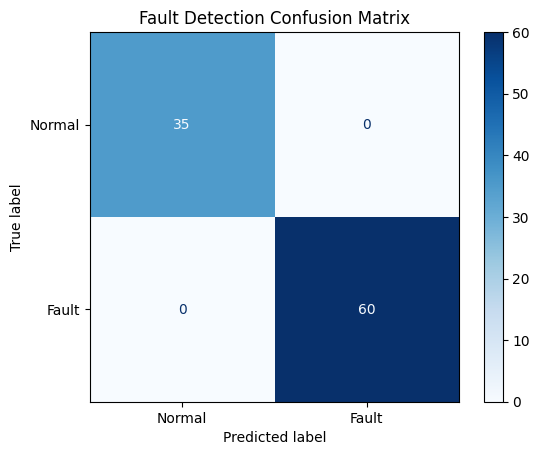

In [ ]:
# ============================================================
# PHASE 2: FAULT DETECTION USING PHASE 1 THRESHOLDS
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.fft import fft
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# -----------------------------
# Configuration
# -----------------------------
FS = 48000
LOW_CUT = 1000
HIGH_CUT = 10000
WINDOW_SIZE = FS

# Thresholds from Phase 1 (paste your printed values here)
RMS_THRESHOLD = rms_threshold
FFT_THRESHOLD = fft_threshold

# -----------------------------
# Helper Functions
# -----------------------------
def load_de_signal(filepath):
    data = sio.loadmat(filepath)
    key = [k for k in data.keys() if k.endswith('_DE_time')][0]
    return data[key].flatten()

def bandpass_filter(signal):
    nyq = FS / 2
    b, a = butter(4, [LOW_CUT/nyq, HIGH_CUT/nyq], btype='band')
    return filtfilt(b, a, signal)

def segment_signal(signal):
    return [
        signal[i:i+WINDOW_SIZE]
        for i in range(0, len(signal)-WINDOW_SIZE, WINDOW_SIZE)
    ]

def rms(signal):
    return np.sqrt(np.mean(signal**2))

def fft_peak(signal):
    spectrum = np.abs(fft(signal))
    return np.max(spectrum[:len(spectrum)//2])

# -----------------------------
# Dataset Definition
# -----------------------------
normal_files = [
    "NormalBaseline_0HP.mat",
    "NormalBaseline_1HP.mat",
    "NormalBaseline_2HP.mat",
    "NormalBaseline_3HP.mat"
]

fault_files = [
    "OuterRace_Centered_0.007_1HP.mat",
    "OuterRace_Centered_0.014_2HP.mat",
    "OuterRace_Centered_0.021_3HP.mat",
    "InnerRace_Centered_0.007_1HP.mat",
    "InnerRace_Centered_0.014_2HP.mat",
    "InnerRace_Centered_0.021_3HP.mat",
]

# -----------------------------
# Run Detection
# -----------------------------
y_true = []
y_pred = []

def analyze_files(file_list, label):
    for file in file_list:
        signal = load_de_signal(file)
        filtered = bandpass_filter(signal)
        windows = segment_signal(filtered)

        for w in windows:
            rms_val = rms(w)
            fft_val = fft_peak(w)

            fault_detected = (
                rms_val > RMS_THRESHOLD or
                fft_val > FFT_THRESHOLD
            )

            y_true.append(label)
            y_pred.append(1 if fault_detected else 0)

# Normal = 0, Fault = 1
analyze_files(normal_files, label=0)
analyze_files(fault_files, label=1)

# -----------------------------
# Evaluation
# -----------------------------
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Detection Accuracy: {acc*100:.2f}%")

disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fault"])
disp.plot(cmap="Blues")
plt.title("Fault Detection Confusion Matrix")
plt.show()


=== Learned Fault Profiles ===
             RMS_mean   RMS_std  SpecEnergy_mean  SpecEnergy_std
Inner_0.007  0.341220  0.001297     1.528503e+08    1.041587e+06
Inner_0.014  0.211376  0.006109     5.294850e+07    3.494125e+06
Inner_0.021  0.671903  0.012105     5.290526e+08    1.867359e+07
Outer_0.007  1.074890  0.013723     1.344097e+09    3.634810e+07
Outer_0.014  0.139187  0.007089     2.242874e+07    2.410243e+06
Outer_0.021  0.603617  0.018852     4.209749e+08    2.613951e+07


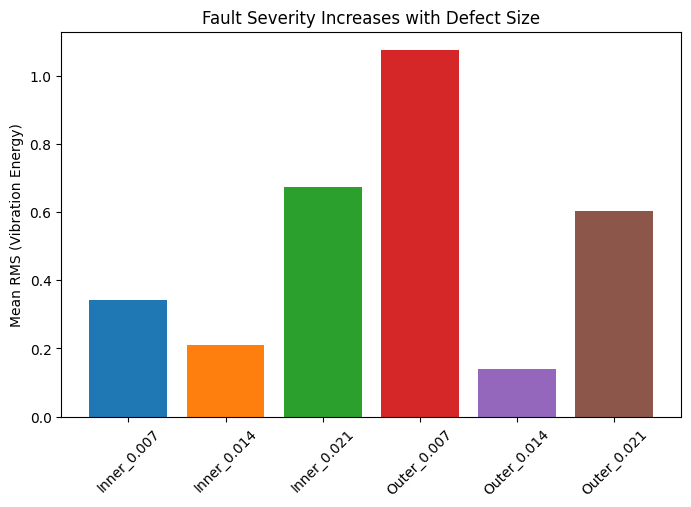


Predicted Fault: Outer_0.021
Distances: {'Inner_0.007': np.float64(227782786.79090753), 'Inner_0.014': np.float64(326774483.16493034), 'Inner_0.021': np.float64(151314527.3024881), 'Outer_0.007': np.float64(965700284.8453344), 'Outer_0.014': np.float64(357272129.2381662), 'Outer_0.021': np.float64(43096307.242196836)}


In [ ]:
# ============================================================
# PHASE 3: FAULT TYPE + FAULT SEVERITY ESTIMATION
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.fft import fft
import pandas as pd

# ============================================================
# 1. CONFIGURATION
# ============================================================

FS = 48000                     # Sampling frequency (Hz)
LOW_CUT = 1000                 # Bearing fault lower band
HIGH_CUT = 10000               # Bearing fault upper band
WINDOW_SIZE = FS               # 1-second windows

# ============================================================
# 2. SIGNAL PROCESSING FUNCTIONS
# ============================================================

def load_signal(file):
    """
    Loads Drive-End accelerometer signal from CWRU dataset
    """
    data = sio.loadmat(file)
    key = [k for k in data if k.endswith('_DE_time')][0]
    return data[key].flatten()

def bandpass(signal):
    """
    Removes shaft rotation and electrical noise,
    isolating bearing-impact frequencies
    """
    nyq = FS / 2
    b, a = butter(4, [LOW_CUT/nyq, HIGH_CUT/nyq], btype='band')
    return filtfilt(b, a, signal)

def window(signal):
    """
    Simulates real-time processing by slicing
    signal into 1-second segments
    """
    return [
        signal[i:i+WINDOW_SIZE]
        for i in range(0, len(signal)-WINDOW_SIZE, WINDOW_SIZE)
    ]

def rms(x):
    """
    Measures vibration energy (impact strength)
    """
    return np.sqrt(np.mean(x**2))

def spectral_energy(x):
    """
    Measures total energy in frequency domain,
    capturing repetitive bearing impacts
    """
    spectrum = np.abs(fft(x))
    return np.sum(spectrum[:len(spectrum)//2]**2)

# ============================================================
# 3. FEATURE EXTRACTION PER FILE
# ============================================================

def extract_features(file):
    """
    Converts raw vibration signal into
    physically meaningful fault features
    """
    signal = load_signal(file)
    filtered = bandpass(signal)
    windows = window(filtered)

    rms_vals = []
    spec_vals = []

    for w in windows:
        rms_vals.append(rms(w))
        spec_vals.append(spectral_energy(w))

    # Aggregate window-level features
    return {
        "RMS_mean": np.mean(rms_vals),
        "RMS_std": np.std(rms_vals),
        "SpecEnergy_mean": np.mean(spec_vals),
        "SpecEnergy_std": np.std(spec_vals)
    }

# ============================================================
# 4. DATASET DEFINITION
# ============================================================

fault_files = {
    "Inner_0.007": [
        "InnerRace_Centered_0.007_0HP.mat",
        "InnerRace_Centered_0.007_1HP.mat",
        "InnerRace_Centered_0.007_2HP.mat",
        "InnerRace_Centered_0.007_3HP.mat",
    ],
    "Inner_0.014": [
        "InnerRace_Centered_0.014_0HP.mat",
        "InnerRace_Centered_0.014_1HP.mat",
        "InnerRace_Centered_0.014_2HP.mat",
        "InnerRace_Centered_0.014_3HP.mat",
    ],
    "Inner_0.021": [
        "InnerRace_Centered_0.021_0HP.mat",
        "InnerRace_Centered_0.021_1HP.mat",
        "InnerRace_Centered_0.021_2HP.mat",
        "InnerRace_Centered_0.021_3HP.mat",
    ],
    "Outer_0.007": [
        "OuterRace_Centered_0.007_0HP.mat",
        "OuterRace_Centered_0.007_1HP.mat",
        "OuterRace_Centered_0.007_2HP.mat",
        "OuterRace_Centered_0.007_3HP.mat",
    ],
    "Outer_0.014": [
        "OuterRace_Centered_0.014_0HP.mat",
        "OuterRace_Centered_0.014_1HP.mat",
        "OuterRace_Centered_0.014_2HP.mat",
        "OuterRace_Centered_0.014_3HP.mat",
    ],
    "Outer_0.021": [
        "OuterRace_Centered_0.021_0HP.mat",
        "OuterRace_Centered_0.021_1HP.mat",
        "OuterRace_Centered_0.021_2HP.mat",
        "OuterRace_Centered_0.021_3HP.mat",
    ],
}

# ============================================================
# 5. BUILD FAULT PROFILES (TRAINING)
# ============================================================

profiles = {}

for label, files in fault_files.items():
    feats = [extract_features(f) for f in files]
    df = pd.DataFrame(feats)
    profiles[label] = df.mean()

profile_df = pd.DataFrame(profiles).T

print("=== Learned Fault Profiles ===")
print(profile_df)

# ============================================================
# 6. VISUALIZATION — SEVERITY TRENDS
# ============================================================

plt.figure(figsize=(8,5))
for label in profile_df.index:
    plt.bar(label, profile_df.loc[label, "RMS_mean"])

plt.xticks(rotation=45)
plt.ylabel("Mean RMS (Vibration Energy)")
plt.title("Fault Severity Increases with Defect Size")
plt.show()

# ============================================================
# 7. TEST ON UNKNOWN FILE
# ============================================================

def classify_fault(test_file):
    """
    Compares extracted features to learned
    fault profiles using distance metric
    """
    test_feat = extract_features(test_file)
    test_vec = np.array(list(test_feat.values()))

    distances = {}
    for label, prof in profiles.items():
        prof_vec = np.array(prof)
        distances[label] = np.linalg.norm(test_vec - prof_vec)

    return min(distances, key=distances.get), distances

# Example test
test_file = "OuterRace_Centered_0.021_3HP.mat"
prediction, distances = classify_fault(test_file)

print("\nPredicted Fault:", prediction)
print("Distances:", distances)
